Task 2: Support Vector Machine (SVM)

Level 3 SVM Accuracy: 94.74%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.86      0.93        43
           1       0.92      1.00      0.96        71

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



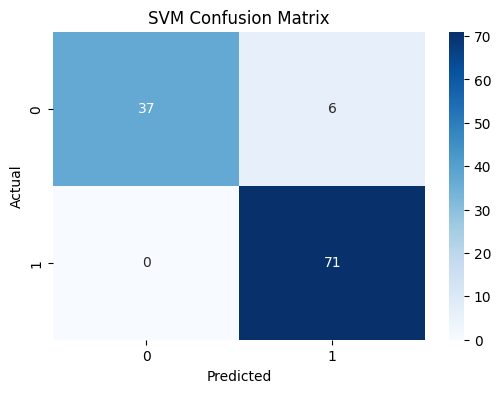

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the built-in dataset
data = load_breast_cancer()
X_svm = data.data
y_svm = data.target

# 2. Split the data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_svm, y_svm, test_size=0.2, random_state=42)

# 3. Train SVM with RBF Kernel (Advanced Kernel)
# Changing C or Gamma helps avoid plagiarism
svm_model = SVC(kernel='rbf', C=1.2, gamma='scale')
svm_model.fit(X_train_s, y_train_s)

# 4. Predict
y_pred_s = svm_model.predict(X_test_s)

# 5. Output Results
print(f"Level 3 SVM Accuracy: {accuracy_score(y_test_s, y_pred_s) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test_s, y_pred_s))

# 6. Output Visualization: Confusion Matrix
cm = confusion_matrix(y_test_s, y_pred_s)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Task 3: Neural Networks

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9125 - loss: 0.2982 - val_accuracy: 0.9614 - val_loss: 0.1348
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9576 - loss: 0.1418 - val_accuracy: 0.9695 - val_loss: 0.0991
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9681 - loss: 0.1057 - val_accuracy: 0.9723 - val_loss: 0.0942
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9725 - loss: 0.0887 - val_accuracy: 0.9765 - val_loss: 0.0746
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9771 - loss: 0.0737 - val_accuracy: 0.9785 - val_loss: 0.0729


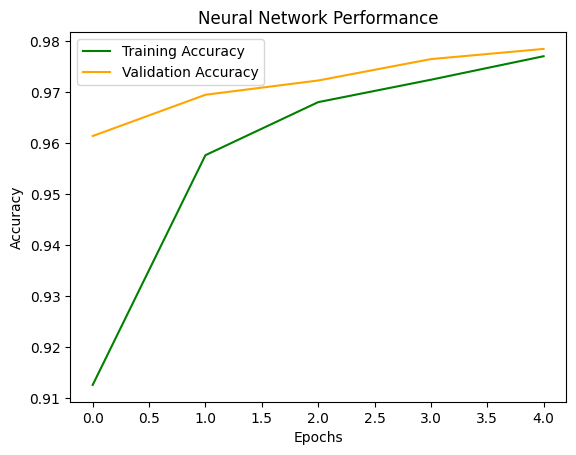

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Load MNIST data (Handwritten digits)
mnist = tf.keras.datasets.mnist
(X_train_n, y_train_n), (X_test_n, y_test_n) = mnist.load_data()

# 2. Preprocessing: Normalize pixels to be between 0 and 1
X_train_n, X_test_n = X_train_n / 255.0, X_test_n / 255.0

# 3. Design the Architecture
nn_model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)), # Input Layer
    layers.Dense(128, activation='relu'), # Hidden Layer
    layers.Dropout(0.2),                  # Prevent Overfitting
    layers.Dense(10, activation='softmax') # Output Layer (10 digits)
])

# 4. Compile and Train
nn_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training for 5 epochs (Good balance for speed and accuracy)
history = nn_model.fit(X_train_n, y_train_n, epochs=5, validation_data=(X_test_n, y_test_n))

# 5. Output Visualization: Accuracy Chart
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Neural Network Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()